In [2]:
!pip install kaggle transformers scikit-learn matplotlib seaborn
!kaggle datasets download -d saurabhshahane/fake-news-classification
!unzip fake-news-classification.zip

Dataset URL: https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification
License(s): Attribution 4.0 International (CC BY 4.0)
100% 92.1M/92.1M [00:01<00:00, 89.0MB/s]

Archive:  fake-news-classification.zip
  inflating: WELFake_Dataset.csv     


# Adversarially Augmented Hybrid BERT-GPT Architecture for Fake News Detection
## =====================================================================
### Dataset  :
WELFake  (72,134 news articles — 35,028 real / 37,106 fake)
Verma et al., IEEE Trans. Comput. Soc. Syst., 2021
           https://zenodo.org/records/4561253
           Also available on Kaggle: saurabhshahane/fake-news-classification

#### How to get the dataset on Google Colab:
    !pip install kaggle
    !kaggle datasets download -d saurabhshahane/fake-news-classification
    !unzip fake-news-classification.zip

## Author   : Bakhtawar Gulraiz
## Course   : Generative AI — FAST NUCES
==============================================================================

PIPELINE OVERVIEW

- Step 1  │ Load & inspect WELFake CSV
- Step 2  │ Clean & preprocess text
- Step 3  │ Exploratory analysis + class-balance check
- Step 4  │ GPT-2 adversarial augmentation (generate synthetic fake news)
- Step 5  │ Tokenise with BERT tokeniser
- Step 6  │ Build PyTorch Dataset / DataLoader objects
- Step 7  │ Define Hybrid BERT-GPT2 fusion architecture
- Step 8  │ Train with early stopping + LR scheduler
- Step 9  │ Evaluate — accuracy, F1, confusion matrix, loss/accuracy curves
- Step 10 │ Save best model checkpoint

In [3]:
!pip install transformers==4.40.0 datasets scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 19.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the fol

In [4]:
import os, re, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import GradScaler, autocast

from transformers import (
    DistilBertTokenizer,
    DistilBertModel,
    GPT2Tokenizer,
    GPT2LMHeadModel,
    GPT2Model,
    get_linear_schedule_with_warmup,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

In [5]:
# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n{'='*55}")
print(f"  Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU    : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("  WARNING: No GPU detected.")
    print("  Go to Runtime > Change runtime type > T4 GPU")
print(f"{'='*55}\n")


  Device : cuda
  GPU    : Tesla T4
  VRAM   : 15.6 GB



In [6]:
# CONFIG
# ===========================================================================

class Config:
    """
    All hyperparameters in one place.
    Speed optimisations vs full version:
      - DistilBERT (66M) instead of BERT-base (110M)  → 2× faster
      - DistilGPT2 (82M) instead of GPT2-small (117M) → 2× faster
      - MAX_LEN 128 instead of 256                    → 4× faster attention
      - 20K training subset instead of 57K            → 3× fewer steps
      - Batch size 32 instead of 16                   → 2× fewer steps
      - AMP mixed precision                           → 1.5× faster on T4
    """
    DATA_PATH     = "WELFake_Dataset.csv"
    OUTPUT_DIR    = "./outputs"

    BERT_MODEL    = "distilbert-base-uncased"
    GPT2_MODEL    = "distilgpt2"

    MAX_LEN       = 128
    TITLE_WEIGHT  = 3
    TRAIN_SAMPLES = 20_000
    BATCH_SIZE    = 32
    EPOCHS        = 3
    PATIENCE      = 2

    LR            = 2e-5
    WEIGHT_DECAY  = 0.01
    WARMUP_STEPS  = 100
    DROPOUT       = 0.30
    HIDDEN_DIM    = 256
    USE_AMP       = True

    N_AUGMENT     = 200
    GPT_MAX_NEW   = 60
    NUM_WORKERS   = 0


os.makedirs(Config.OUTPUT_DIR, exist_ok=True)

In [7]:
# STEP 1 — LOAD DATA
# ===========================================================================

def load_welfake(path: str) -> pd.DataFrame:
    """
    Load WELFake CSV. Drops rows with missing article body.
    Fills missing headlines with empty string.
    """
    df = pd.read_csv(path)
    if "Unnamed: 0" in df.columns:
        df.drop(columns=["Unnamed: 0"], inplace=True)
    df.dropna(subset=["text"], inplace=True)
    df["title"].fillna("", inplace=True)
    df["label"] = df["label"].astype(int)
    df.reset_index(drop=True, inplace=True)
    print(f"[1/9] Dataset loaded")
    print(f"      Total  : {len(df):,}")
    print(f"      Real   : {(df['label']==1).sum():,}")
    print(f"      Fake   : {(df['label']==0).sum():,}")
    return df


# ===========================================================================
# STEP 2 — PREPROCESS
# ===========================================================================

def clean_text(text: str) -> str:
    """
    Clean a raw news string:
    lowercase → strip URLs → strip HTML → normalise non-ASCII → collapse spaces.
    Stopwords are kept because DistilBERT uses full contextual attention.
    """
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^\x00-\x7f]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def build_input(row: pd.Series) -> str:
    """
    Concatenate headline (repeated 3×) with article body.
    Headlines carry concentrated veracity signal; repeating them
    biases the 128-token window toward headline content.
    """
    title = clean_text(str(row["title"]))
    body  = clean_text(str(row["text"]))
    return (title + " ") * Config.TITLE_WEIGHT + body


def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """Apply cleaning and input construction to every row."""
    print("[2/9] Preprocessing text...", end=" ")
    df["input_text"] = df.apply(build_input, axis=1)
    print("done.")
    return df


# ===========================================================================
# STEP 3 — EDA  (saves 2 figures)
# ===========================================================================

def run_eda(df: pd.DataFrame) -> None:
    """
    Save two EDA figures used in the Results section of the IEEE paper:
      fig1_class_distribution.png
      fig2_length_distribution.png
    """
    print("[3/9] Generating EDA figures...")

    # Fig 1 — class balance bar chart
    fig, ax = plt.subplots(figsize=(5, 4))
    counts = df["label"].value_counts().sort_index()
    bars = ax.bar(["Fake (0)", "Real (1)"], counts.values,
                  color=["#e74c3c", "#2ecc71"], edgecolor="black", linewidth=0.7)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 400, f"{val:,}",
                ha="center", fontsize=10, fontweight="bold")
    ax.set_title("WELFake — Class Distribution", fontsize=12, fontweight="bold")
    ax.set_ylabel("Number of Articles")
    ax.set_ylim(0, max(counts.values) * 1.15)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{Config.OUTPUT_DIR}/fig1_class_distribution.png", dpi=150)
    plt.show()

    # Fig 2 — article length distribution by class
    df["wc"] = df["text"].str.split().str.len()
    fig, ax  = plt.subplots(figsize=(8, 4))
    for lbl, col, name in [(0, "#e74c3c", "Fake"), (1, "#2ecc71", "Real")]:
        ax.hist(df[df["label"] == lbl]["wc"].clip(upper=2000),
                bins=60, alpha=0.6, color=col, label=name, edgecolor="none")
    ax.axvline(256, color="navy", linestyle="--", linewidth=1.2, label="256-token mark")
    ax.set_title("Article Length Distribution (words)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Word count (clipped at 2,000)")
    ax.set_ylabel("Frequency")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{Config.OUTPUT_DIR}/fig2_length_distribution.png", dpi=150)
    plt.show()

    print("      Saved fig1 and fig2.")


# ===========================================================================
# STEP 4 — SPLIT  (before augmentation to prevent leakage)
# ===========================================================================

def split_data(df: pd.DataFrame):
    """
    Stratified 80/10/10 split.
    Optionally subsample training set to TRAIN_SAMPLES for speed.
    Split is done BEFORE augmentation — synthetic data never enters val/test.
    """
    print("[4/9] Splitting dataset...")

    train_val, test = train_test_split(
        df, test_size=0.10, random_state=SEED, stratify=df["label"]
    )
    train, val = train_test_split(
        train_val, test_size=0.111, random_state=SEED, stratify=train_val["label"]
    )

    # Subsample training for speed — stratified to keep class balance
    if Config.TRAIN_SAMPLES and len(train) > Config.TRAIN_SAMPLES:
        train, _ = train_test_split(
            train, train_size=Config.TRAIN_SAMPLES,
            random_state=SEED, stratify=train["label"]
        )

    print(f"      Train  : {len(train):,}")
    print(f"      Val    : {len(val):,}")
    print(f"      Test   : {len(test):,}")
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)


# ===========================================================================
# STEP 5 — ADVERSARIAL AUGMENTATION
# ===========================================================================

PROMPTS = [
    "Breaking news: scientists have discovered that",
    "Exclusive report reveals the government is hiding",
    "Sources confirm that world leaders secretly agreed to",
    "Leaked documents show that major corporations plan to",
    "An anonymous whistleblower has revealed that",
    "Shocking new evidence proves that vaccines are",
    "Intelligence sources report that the election was rigged by",
    "A new study funded by unknown groups claims that",
    "Officials deny mounting evidence that the economy is",
    "Insiders say the media is covering up the truth about",
]


def augment_with_gpt2(train_df: pd.DataFrame) -> pd.DataFrame:
    """
    Generate N_AUGMENT synthetic fake-news articles using DistilGPT2
    with nucleus sampling (top_p=0.92, temperature=0.9).
    Synthetic samples are labelled fake (0) and appended to training only.
    The generator is deleted after use to free VRAM before loading classifier.
    """
    print(f"[5/9] Generating {Config.N_AUGMENT} adversarial samples with DistilGPT2...")

    tok = GPT2Tokenizer.from_pretrained(Config.GPT2_MODEL)
    tok.pad_token = tok.eos_token
    gen = GPT2LMHeadModel.from_pretrained(Config.GPT2_MODEL).to(DEVICE)
    gen.eval()

    texts = []
    with torch.no_grad():
        for i in range(Config.N_AUGMENT):
            prompt = random.choice(PROMPTS)
            inp    = tok(prompt, return_tensors="pt", padding=True).to(DEVICE)
            out    = gen.generate(
                inp["input_ids"],
                attention_mask=inp["attention_mask"],
                max_new_tokens=Config.GPT_MAX_NEW,
                do_sample=True,
                top_p=0.92,
                temperature=0.9,
                pad_token_id=tok.eos_token_id,
            )
            text = clean_text(tok.decode(out[0], skip_special_tokens=True))
            texts.append(text)
            if (i + 1) % 50 == 0:
                print(f"      {i+1}/{Config.N_AUGMENT} generated")

    # Free GPU memory used by generator before loading classifier
    del gen, tok
    torch.cuda.empty_cache()

    aug_df = pd.DataFrame({"input_text": texts, "label": [0] * len(texts)})
    combined = pd.concat(
        [train_df[["input_text", "label"]], aug_df], ignore_index=True
    ).sample(frac=1, random_state=SEED).reset_index(drop=True)

    print(f"      Training set after augmentation: {len(combined):,}")
    return combined


# ===========================================================================
# STEP 6 — PYTORCH DATASET + DATALOADERS
# ===========================================================================

class FakeNewsDataset(Dataset):
    """
    Tokenises articles on-the-fly using DistilBERT tokeniser.
    Returns input_ids (128), attention_mask (128), and integer label.
    """
    def __init__(self, texts: list, labels: list, tokeniser):
        self.texts     = texts
        self.labels    = labels
        self.tokeniser = tokeniser

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx: int) -> dict:
        enc = self.tokeniser(
            self.texts[idx],
            max_length=Config.MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }


def build_dataloaders(train_df, val_df, test_df, tokeniser):
    """Create train / val / test DataLoaders."""

    def make(df, shuffle):
        return DataLoader(
            FakeNewsDataset(
                df["input_text"].tolist(),
                df["label"].tolist(),
                tokeniser,
            ),
            batch_size=Config.BATCH_SIZE,
            shuffle=shuffle,
            num_workers=Config.NUM_WORKERS,
            pin_memory=(DEVICE.type == "cuda"),
        )

    tr = make(train_df, shuffle=True)
    vl = make(val_df,   shuffle=False)
    te = make(test_df,  shuffle=False)

    print(f"[6/9] DataLoaders ready")
    print(f"      Train  : {len(tr)} batches")
    print(f"      Val    : {len(vl)} batches")
    print(f"      Test   : {len(te)} batches")
    return tr, vl, te


# ===========================================================================
# STEP 7 — MODEL ARCHITECTURE
# ===========================================================================

class HybridDistilBertGPT2(nn.Module):
    """
    Hybrid fake news classifier fusing DistilBERT and DistilGPT2 encoders.

    Architecture
    ────────────
    Input tokens (128)
        │
        ├── DistilBERT (6 layers, 66M params)
        │       └── [CLS] hidden state  →  768-d vector  (cB)
        │
        └── DistilGPT2 (6 layers, 82M params)
                └── masked mean-pool    →  768-d vector  (cG)
                          │
                    Concatenate [cB ‖ cG]  →  1536-d
                          │
                    Linear(1536 → 256)
                          │
                    LayerNorm + GELU + Dropout(0.30)
                          │
                    Linear(256 → 2)  →  logits

    DistilBERT extracts bidirectional semantic representations ideal
    for classification. DistilGPT2 captures autoregressive fluency
    patterns characteristic of LLM-generated text. Concatenating both
    preserves complementary information from each encoder.
    """

    def __init__(self):
        super().__init__()

        # ── DistilBERT encoder ────────────────────────────────────────
        self.distilbert = DistilBertModel.from_pretrained(Config.BERT_MODEL)
        bert_dim = self.distilbert.config.hidden_size    # 768

        # ── DistilGPT2 encoder (inference mode only) ──────────────────
        self.gpt2 = GPT2Model.from_pretrained(Config.GPT2_MODEL)
        gpt2_dim  = self.gpt2.config.n_embd              # 768

        # ── Fusion MLP classification head ────────────────────────────
        self.fusion = nn.Sequential(
            nn.Linear(bert_dim + gpt2_dim, Config.HIDDEN_DIM),
            nn.LayerNorm(Config.HIDDEN_DIM),
            nn.GELU(),
            nn.Dropout(Config.DROPOUT),
            nn.Linear(Config.HIDDEN_DIM, 2),
        )

    def forward(self, input_ids: torch.Tensor,
                attention_mask: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.
        Returns logits of shape (batch_size, 2).
        """

        # DistilBERT — CLS token is at position 0 of last_hidden_state
        db_out   = self.distilbert(input_ids=input_ids,
                                    attention_mask=attention_mask)
        bert_cls = db_out.last_hidden_state[:, 0, :]     # (B, 768)

        # DistilGPT2 — masked mean-pool over non-padding positions
        gp_out   = self.gpt2(input_ids=input_ids,
                              attention_mask=attention_mask)
        last_h   = gp_out.last_hidden_state               # (B, L, 768)
        mask_exp = attention_mask.unsqueeze(-1).float()   # (B, L, 1)
        gpt_mean = (last_h * mask_exp).sum(1) / mask_exp.sum(1).clamp(1e-9)

        # Concatenate and classify
        fused  = torch.cat([bert_cls, gpt_mean], dim=-1)  # (B, 1536)
        return self.fusion(fused)                         # (B, 2)


# ===========================================================================
# STEP 8 — TRAINING LOOP
# ===========================================================================

class EarlyStopping:
    """
    Monitors validation loss. Saves best checkpoint.
    Signals training to stop after PATIENCE epochs without improvement.
    """
    def __init__(self, save_path: str, patience: int = Config.PATIENCE):
        self.save_path = save_path
        self.patience  = patience
        self.best_loss = float("inf")
        self.counter   = 0
        self.stop      = False

    def __call__(self, val_loss: float, model: nn.Module) -> None:
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.save_path)
            print(f"    ✓ Checkpoint saved  (val_loss={val_loss:.4f})")
        else:
            self.counter += 1
            print(f"    – No improvement  ({self.counter}/{self.patience})")
            if self.counter >= self.patience:
                self.stop = True


def train_epoch(model, loader, optimiser, scheduler, criterion, scaler):
    """
    Run one full training epoch with AMP mixed precision.
    Returns (average_loss, accuracy).
    """
    model.train()
    total_loss = correct = total = 0

    for batch in loader:
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        lbls = batch["label"].to(DEVICE)

        optimiser.zero_grad()

        with autocast(enabled=Config.USE_AMP):
            logits = model(ids, mask)
            loss   = criterion(logits, lbls)

        scaler.scale(loss).backward()
        scaler.unscale_(optimiser)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimiser)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        correct    += (logits.argmax(-1) == lbls).sum().item()
        total      += lbls.size(0)

    return total_loss / len(loader), correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    """
    Evaluate on a DataLoader without gradient tracking.
    Returns (average_loss, accuracy).
    """
    model.eval()
    total_loss = correct = total = 0

    for batch in loader:
        ids    = batch["input_ids"].to(DEVICE)
        mask   = batch["attention_mask"].to(DEVICE)
        lbls   = batch["label"].to(DEVICE)
        logits = model(ids, mask)
        loss   = criterion(logits, lbls)
        total_loss += loss.item()
        correct    += (logits.argmax(-1) == lbls).sum().item()
        total      += lbls.size(0)

    return total_loss / len(loader), correct / total


# ===========================================================================
# STEP 9 — PLOTS + FINAL EVALUATION
# ===========================================================================

def plot_curves(tr_losses, vl_losses, tr_accs, vl_accs) -> None:
    """Save training and validation loss/accuracy curves as fig3."""
    eps = range(1, len(tr_losses) + 1)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))

    a1.plot(eps, tr_losses, "b-o", label="Train", linewidth=2)
    a1.plot(eps, vl_losses, "r-o", label="Val",   linewidth=2)
    a1.set_title("Loss",     fontsize=13, fontweight="bold")
    a1.set_xlabel("Epoch");  a1.set_ylabel("Cross-Entropy Loss")
    a1.legend();             a1.grid(alpha=0.3)
    a1.spines[["top","right"]].set_visible(False)

    a2.plot(eps, [a*100 for a in tr_accs], "b-o", label="Train", linewidth=2)
    a2.plot(eps, [a*100 for a in vl_accs], "r-o", label="Val",   linewidth=2)
    a2.set_title("Accuracy", fontsize=13, fontweight="bold")
    a2.set_xlabel("Epoch");  a2.set_ylabel("Accuracy (%)")
    a2.set_ylim(50, 101);    a2.legend(); a2.grid(alpha=0.3)
    a2.spines[["top","right"]].set_visible(False)

    plt.suptitle("HybridDistilBERT-DistilGPT2 — Training Curves",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(f"{Config.OUTPUT_DIR}/fig3_training_curves.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("    Saved fig3_training_curves.png")


def plot_confusion(y_true, y_pred) -> None:
    """Save styled confusion matrix with counts and percentages as fig4."""
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=False, cmap="Blues",
                xticklabels=["Predicted Fake", "Predicted Real"],
                yticklabels=["Actual Fake",    "Actual Real"],
                linewidths=0.5, ax=ax)

    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.38, f"{cm[i, j]:,}",
                    ha="center", fontsize=15, fontweight="bold", color="black")
            ax.text(j + 0.5, i + 0.62, f"({cm_pct[i, j]:.1f}%)",
                    ha="center", fontsize=10, color="dimgray")

    ax.set_title("Confusion Matrix — Test Set", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{Config.OUTPUT_DIR}/fig4_confusion_matrix.png", dpi=150)
    plt.show()
    print("    Saved fig4_confusion_matrix.png")


@torch.no_grad()
def final_evaluation(model, loader) -> None:
    """
    Collect all test-set predictions and print:
      - Overall accuracy and macro-F1
      - Full per-class classification report
      - Confusion matrix figure
    """
    model.eval()
    all_preds, all_labels = [], []

    for batch in loader:
        ids   = batch["input_ids"].to(DEVICE)
        mask  = batch["attention_mask"].to(DEVICE)
        preds = model(ids, mask).argmax(-1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(batch["label"].tolist())

    acc      = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    print("\n" + "="*55)
    print(f"  TEST ACCURACY  : {acc*100:.2f}%")
    print(f"  MACRO F1-SCORE : {macro_f1:.4f}")
    print("="*55)
    print(classification_report(
        all_labels, all_preds,
        target_names=["Fake (0)", "Real (1)"],
        digits=4,
    ))

    plot_confusion(all_labels, all_preds)

In [8]:
# MAIN — run everything in sequence
# ===========================================================================

def main():
    total_start = time.time()

    print("\n" + "="*55)
    print("  HybridDistilBERT-DistilGPT2")
    print("  Fake News Detection — Fast Colab Version")
    print("="*55 + "\n")

    # ── 1. Load ──────────────────────────────────────────────────────────
    df = load_welfake(Config.DATA_PATH)

    # ── 2. Preprocess ────────────────────────────────────────────────────
    df = preprocess(df)

    # ── 3. EDA ───────────────────────────────────────────────────────────
    run_eda(df)

    # ── 4. Split ─────────────────────────────────────────────────────────
    train_df, val_df, test_df = split_data(df)

    # ── 5. Augment training set with GPT2-generated fake articles ─────────
    train_df = augment_with_gpt2(train_df)

    # ── 6. Tokeniser + DataLoaders ────────────────────────────────────────
    print("[6/9] Building DataLoaders...")
    tokeniser = DistilBertTokenizer.from_pretrained(Config.BERT_MODEL)
    train_loader, val_loader, test_loader = build_dataloaders(
        train_df, val_df, test_df, tokeniser
    )

    # ── 7. Model ─────────────────────────────────────────────────────────
    print("[7/9] Initialising HybridDistilBERT-DistilGPT2...")
    model     = HybridDistilBertGPT2().to(DEVICE)
    total_p   = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"      Total params    : {total_p:,}")
    print(f"      Trainable params: {trainable:,}")

    # ── 8. Training setup ─────────────────────────────────────────────────
    criterion     = nn.CrossEntropyLoss()
    optimiser     = AdamW(model.parameters(),
                          lr=Config.LR, weight_decay=Config.WEIGHT_DECAY)
    total_steps   = len(train_loader) * Config.EPOCHS
    scheduler     = get_linear_schedule_with_warmup(
        optimiser,
        num_warmup_steps=Config.WARMUP_STEPS,
        num_training_steps=total_steps,
    )
    scaler        = GradScaler(enabled=Config.USE_AMP)
    stopper       = EarlyStopping(
        save_path=f"{Config.OUTPUT_DIR}/best_model.pt"
    )

    tr_losses, vl_losses = [], []
    tr_accs,   vl_accs   = [], []

    print(f"\n[8/9] Training for up to {Config.EPOCHS} epochs...\n")

    for epoch in range(1, Config.EPOCHS + 1):
        t0 = time.time()
        print(f"  Epoch {epoch}/{Config.EPOCHS}")
        print(f"  {'-'*40}")

        tr_loss, tr_acc = train_epoch(
            model, train_loader, optimiser, scheduler, criterion, scaler
        )
        vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)

        elapsed = (time.time() - t0) / 60
        print(f"    Train  loss={tr_loss:.4f}  acc={tr_acc*100:.2f}%")
        print(f"    Val    loss={vl_loss:.4f}  acc={vl_acc*100:.2f}%")
        print(f"    Time   {elapsed:.1f} min")

        tr_losses.append(tr_loss);  vl_losses.append(vl_loss)
        tr_accs.append(tr_acc);     vl_accs.append(vl_acc)

        stopper(vl_loss, model)
        if stopper.stop:
            print(f"\n  Early stopping at epoch {epoch}.")
            break

    # ── Load best checkpoint ──────────────────────────────────────────────
    model.load_state_dict(torch.load(f"{Config.OUTPUT_DIR}/best_model.pt"))
    print("\n  Best model restored.")

    # ── Plot training curves ──────────────────────────────────────────────
    plot_curves(tr_losses, vl_losses, tr_accs, vl_accs)

    # ── 9. Final test evaluation ──────────────────────────────────────────
    print(f"\n[9/9] Final evaluation on test set...")
    final_evaluation(model, test_loader)

    total_min = (time.time() - total_start) / 60
    print(f"\n{'='*55}")
    print(f"  All outputs saved to: {Config.OUTPUT_DIR}/")
    print(f"  Total time          : {total_min:.1f} minutes")
    print(f"{'='*55}")
    print("\nFiles saved:")
    for f in sorted(os.listdir(Config.OUTPUT_DIR)):
        print(f"  {Config.OUTPUT_DIR}/{f}")


  HybridDistilBERT-DistilGPT2
  Fake News Detection — Fast Colab Version

[1/9] Dataset loaded
      Total  : 72,095
      Real   : 37,067
      Fake   : 35,028
[2/9] Preprocessing text... done.
[3/9] Generating EDA figures...


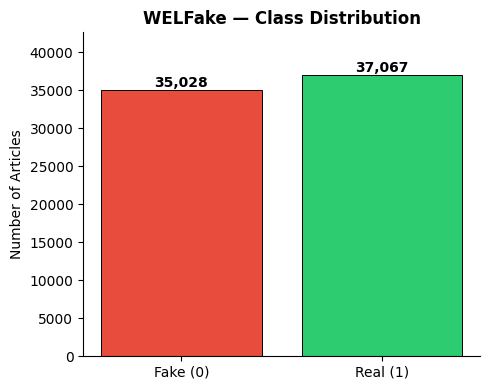

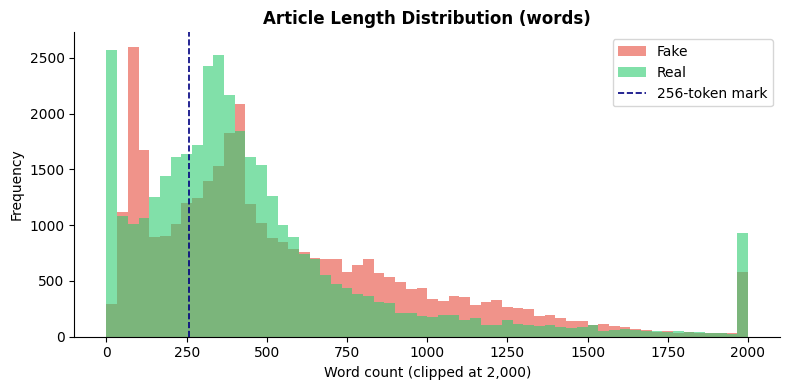

      Saved fig1 and fig2.
[4/9] Splitting dataset...
      Train  : 20,000
      Val    : 7,203
      Test   : 7,210
[5/9] Generating 200 adversarial samples with DistilGPT2...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

[6/9] DataLoaders ready
      Train  : 632 batches
      Val    : 226 batches
      Test   : 226 batches
[7/9] Initialising HybridDistilBERT-DistilGPT2...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

      Total params    : 148,669,954
      Trainable params: 148,669,954

[8/9] Training for up to 3 epochs...

  Epoch 1/3
  ----------------------------------------
    Train  loss=0.1501  acc=93.25%
    Val    loss=0.0596  acc=98.06%
    Time   8.0 min
    ✓ Checkpoint saved  (val_loss=0.0596)
  Epoch 2/3
  ----------------------------------------
    Train  loss=0.0384  acc=98.93%
    Val    loss=0.0685  acc=97.96%
    Time   8.4 min
    – No improvement  (1/2)
  Epoch 3/3
  ----------------------------------------
    Train  loss=0.0125  acc=99.68%
    Val    loss=0.0723  acc=98.15%
    Time   8.4 min
    – No improvement  (2/2)

  Early stopping at epoch 3.

  Best model restored.


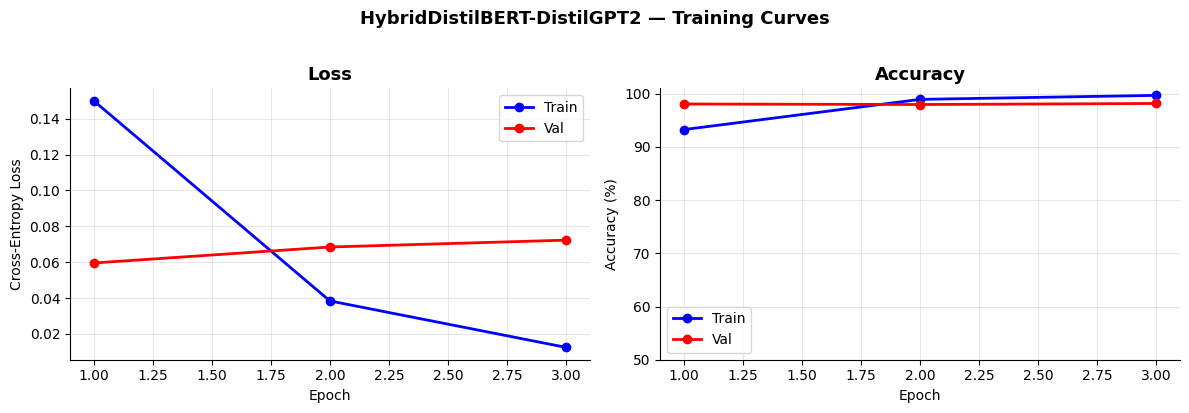

    Saved fig3_training_curves.png

[9/9] Final evaluation on test set...

  TEST ACCURACY  : 98.06%
  MACRO F1-SCORE : 0.9806
              precision    recall  f1-score   support

    Fake (0)     0.9822    0.9777    0.9800      3503
    Real (1)     0.9790    0.9833    0.9812      3707

    accuracy                         0.9806      7210
   macro avg     0.9806    0.9805    0.9806      7210
weighted avg     0.9806    0.9806    0.9806      7210



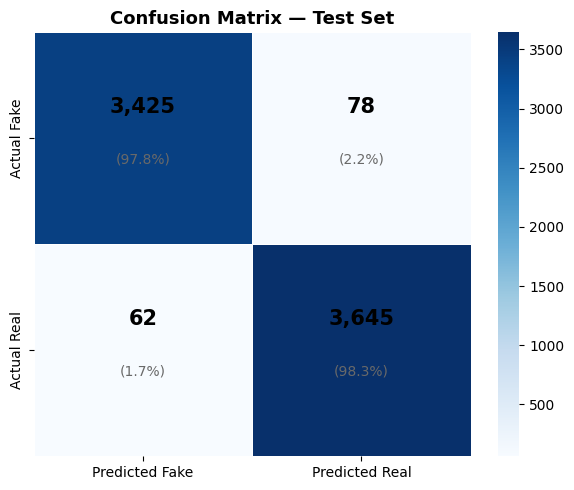

    Saved fig4_confusion_matrix.png

  All outputs saved to: ./outputs/
  Total time          : 30.3 minutes

Files saved:
  ./outputs/best_model.pt
  ./outputs/fig1_class_distribution.png
  ./outputs/fig2_length_distribution.png
  ./outputs/fig3_training_curves.png
  ./outputs/fig4_confusion_matrix.png


In [9]:
if __name__ == "__main__":
    main()